In [1]:
# Import Bladder + Normal for detection model training
import pandas as pd
from sklearn.utils import shuffle

df = pd.read_csv("Dataset/bladder+normal.csv")
df = shuffle(df, random_state=42).reset_index(drop=True)
display(df.head(5))
display(df.shape)

,cancer_type,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,normal,normal,10.154073,6.229753,4.726761,7.694610,3.036633,7.709174,4.876000,5.498816,...,12.301864,11.774613,13.769954,13.445276,8.039906,7.075380,7.236685,3.213733,3.253917,3.309950
1,bladder,tumoral_urothelia,5.448550,2.855473,3.956391,6.990753,2.515888,4.532908,5.148095,3.420617,...,12.355006,12.073772,13.375017,13.129036,14.285014,12.222636,13.764253,2.635243,3.087296,2.749863
2,normal,normal,11.113545,5.940342,5.564016,8.278557,3.737454,8.904443,6.310405,5.029888,...,12.440360,11.836593,13.794074,13.652361,10.184499,5.065497,7.553789,3.308568,3.670986,3.624235
3,bladder,tumoral_urothelia,6.117643,2.963498,4.462724,7.637291,2.748184,4.799081,5.387159,3.796579,...,13.488239,13.297656,14.433989,14.138876,8.479708,3.234453,3.255350,2.217603,2.700261,2.564158
4,bladder,tumoral_urothelia,6.341556,2.839390,4.035876,6.989258,2.344312,5.291725,5.210843,3.260132,...,12.746157,12.766855,14.151366,13.834423,8.481049,3.886499,3.866914,2.422337,2.591235,2.733775


(86, 54677)

In [2]:
# Preprocessing data
# Input df, return X,y for training
from sklearn.utils import shuffle

def preprocessing(df):
    
    # Drop type Columns
    if "type" in df.columns:
        df = df.drop(columns="type")

    # Convert label to binary type:
    if 'cancer_type' in df.columns and not df['cancer_type'].isin([0, 1]).all():
        df['cancer_type'] = df['cancer_type'].map({'bladder': 1, 'normal': 0})
    
    # Get X,y
    target = 'cancer_type'
    X = df.drop(columns=target)
    y = df[target]
    
    return X,y

# Display proccesed data

X,y = preprocessing(df)
display(X,y)

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,10.154073,6.229753,4.726761,7.694610,3.036633,7.709174,4.876000,5.498816,7.182190,3.183595,...,12.301864,11.774613,13.769954,13.445276,8.039906,7.075380,7.236685,3.213733,3.253917,3.309950
1,5.448550,2.855473,3.956391,6.990753,2.515888,4.532908,5.148095,3.420617,3.378807,3.022539,...,12.355006,12.073772,13.375017,13.129036,14.285014,12.222636,13.764253,2.635243,3.087296,2.749863
2,11.113545,5.940342,5.564016,8.278557,3.737454,8.904443,6.310405,5.029888,6.557580,3.570486,...,12.440360,11.836593,13.794074,13.652361,10.184499,5.065497,7.553789,3.308568,3.670986,3.624235
3,6.117643,2.963498,4.462724,7.637291,2.748184,4.799081,5.387159,3.796579,2.914434,2.863601,...,13.488239,13.297656,14.433989,14.138876,8.479708,3.234453,3.255350,2.217603,2.700261,2.564158
4,6.341556,2.839390,4.035876,6.989258,2.344312,5.291725,5.210843,3.260132,4.015626,2.747104,...,12.746157,12.766855,14.151366,13.834423,8.481049,3.886499,3.866914,2.422337,2.591235,2.733775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,5.877810,2.981233,4.215136,7.057191,3.241641,4.873606,5.360925,3.586231,2.815725,2.888503,...,12.849960,12.797338,14.239379,13.820882,9.966319,4.201960,7.081000,2.342733,2.739011,2.685265
82,9.175141,6.997110,8.655219,7.637841,3.333808,8.305916,4.716150,4.623700,10.296539,3.551861,...,12.803370,12.260684,13.924746,13.542926,9.461209,7.386210,8.320564,3.277732,3.597326,3.219145
83,9.775815,5.804580,4.975438,10.190593,2.673737,7.160313,5.601028,4.508930,5.299688,4.462494,...,12.813202,12.134137,13.953880,13.851152,9.954725,7.662682,8.721134,2.616275,2.854682,2.903801
84,6.253289,2.976346,4.285171,7.196972,2.646898,4.677947,5.756575,3.184499,2.633751,2.912722,...,12.881227,12.819549,14.203416,13.831713,10.343228,4.501393,7.557837,2.324029,2.526199,2.722077


0     0
1     1
2     0
3     1
4     1
     ..
81    1
82    0
83    0
84    1
85    0
Name: cancer_type, Length: 86, dtype: int64

In [11]:
# Method 1: Variance Threshold (Assume Features with higher variance => better)
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

threshold = 0.001
selector = VarianceThreshold(threshold=threshold)
X_var = selector.fit_transform(X)

selected_feature_indices = selector.get_support(indices=True)
X_var = X.columns[selected_feature_indices]
print(f"Number of selected features: {len(X_var)}")
print(f"Selected features: {X_var}")

Number of selected features: 54675
Selected features: Index(['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at',
       '1316_at', '1320_at', '1405_i_at', '1431_at',
       ...
       'AFFX-r2-Ec-bioD-3_at', 'AFFX-r2-Ec-bioD-5_at', 'AFFX-r2-P1-cre-3_at',
       'AFFX-r2-P1-cre-5_at', 'AFFX-ThrX-3_at', 'AFFX-ThrX-5_at',
       'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at', 'AFFX-TrpnX-5_at',
       'AFFX-TrpnX-M_at'],
      dtype='object', length=54675)


#### Because the dataset is already normalized, the variance is not so different => All gene is selected with vaiance threshold method => This method is not apporpriate

In [18]:
# Method 2: Unvariate feature selection method (Based on their relation with output)
# ANOVA f-statistics

from sklearn.feature_selection import SelectKBest, f_classif

# Select top 1000 features based on ANOVA F-statistic
k_best_selector = SelectKBest(score_func=f_classif, k=500)
X_anova = k_best_selector.fit_transform(X, y)

# Get selected feature names
X_anova = X.columns[k_best_selector.get_support()]

print(f"Selected features: {X_anova}")

Selected features: Index(['1553103_at', '1553587_a_at', '1554510_s_at', '1554600_s_at',
       '1555226_s_at', '1555764_s_at', '1555780_a_at', '1556285_s_at',
       '1861_at', '200051_at',
       ...
       '35685_at', '37943_at', '44669_at', '45288_at', '45828_at',
       '48031_r_at', '49679_s_at', '52164_at', '52940_at', '55583_at'],
      dtype='object', length=500)


In [19]:
# Method 3: Mutual Information methnod (Non-linear relationship between predictors and targets)

from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Select top 100 features based on Mutual Information
mutual_info_selector = SelectKBest(score_func=mutual_info_classif, k=500)
X_mut = mutual_info_selector.fit_transform(X, y)

# Get selected feature names
X_mut = X.columns[mutual_info_selector.get_support()]

print(f"Selected features: {X_mut}")


Selected features: Index(['225258_at', '225260_s_at', '225261_x_at', '225264_at', '225270_at',
       '225272_at', '225277_at', '225298_at', '225307_at', '225312_at',
       ...
       '58994_at', '59625_at', '59631_at', '59705_at', '61734_at',
       '64408_s_at', '64474_g_at', '64488_at', '65718_at', '79005_at'],
      dtype='object', length=500)


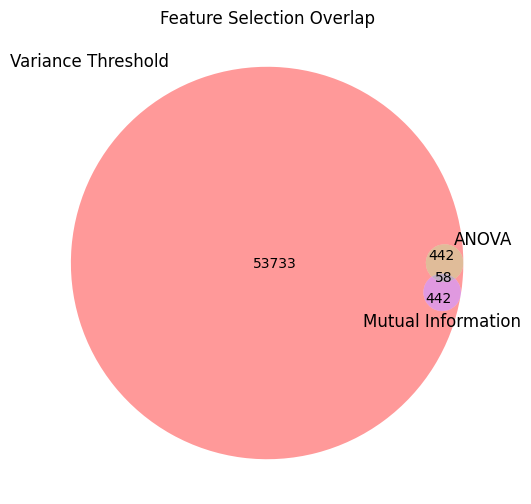

In [20]:
# Convert numpy arrays to flattened lists for compatibility
variance_features = set(X_var.ravel())
anova_features = set(X_anova.ravel())
mutual_info_features = set(X_mut.ravel())

# Create a Venn diagram to visualize the overlap
plt.figure(figsize=(8, 6))
venn_diagram = venn3(
    subsets=(
        len(variance_features - anova_features - mutual_info_features),  # Only Variance
        len(anova_features - variance_features - mutual_info_features),  # Only ANOVA
        len(variance_features & anova_features - mutual_info_features),  # Variance & ANOVA
        len(mutual_info_features - variance_features - anova_features),  # Only Mutual Info
        len(variance_features & mutual_info_features - anova_features),  # Variance & Mutual Info
        len(anova_features & mutual_info_features - variance_features),  # ANOVA & Mutual Info
        len(variance_features & anova_features & mutual_info_features),  # All 3 Methods
    ),
    set_labels=("Variance Threshold", "ANOVA", "Mutual Information"),
)
plt.title("Feature Selection Overlap")
plt.show()


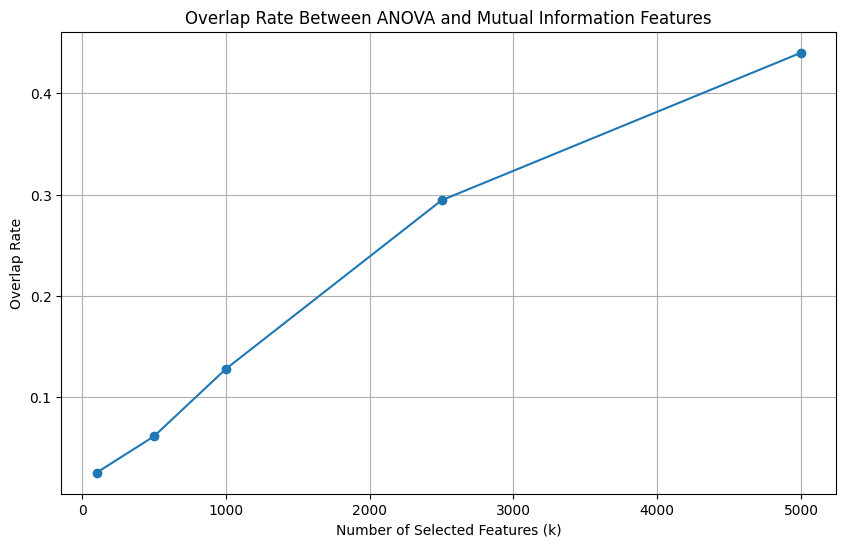

In [22]:
def compare_overlap_rates(X, y, k_values, variance_features):
    """
    Compare and visualize the overlap rates between ANOVA and Mutual Information feature selection.

    Parameters:
    - X: DataFrame of input features.
    - y: Target variable.
    - k_values: List of k values to test.
    - variance_features: Set of features selected by Variance Threshold.

    Returns:
    - None (displays a plot).
    """
    overlap_rates = []

    for k in k_values:
        # Select features using ANOVA
        anova_selector = SelectKBest(score_func=f_classif, k=k)
        anova_features = set(X.columns[anova_selector.fit(X, y).get_support()])

        # Select features using Mutual Information
        mutual_info_selector = SelectKBest(score_func=mutual_info_classif, k=k)
        mutual_info_features = set(X.columns[mutual_info_selector.fit(X, y).get_support()])

        # Calculate overlap rate (intersection / union)
        overlap = len(anova_features & mutual_info_features)
        union = len(anova_features | mutual_info_features)
        overlap_rate = overlap / union if union > 0 else 0

        overlap_rates.append(overlap_rate)

    # Plot overlap rates
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, overlap_rates, marker="o", linestyle="-")
    plt.title("Overlap Rate Between ANOVA and Mutual Information Features")
    plt.xlabel("Number of Selected Features (k)")
    plt.ylabel("Overlap Rate")
    plt.grid(True)
    plt.show()

# Example usage:
k_values = [100, 500, 1000, 2500, 5000]  # Varying number of features to select
variance_features = set(X.columns)  # Variance Threshold includes all features here
compare_overlap_rates(X, y, k_values, variance_features)


In [5]:
# Logistic Regression with l1, saga solver, and ANOVA features selection method
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
import numpy as np

# Step 1: ANOVA for Feature Ranking
k = 100  # Number of features to select
selector = SelectKBest(score_func=f_classif, k=k)
X_anova_selected = selector.fit_transform(X, y)

# Get the indices of the top-k features selected by ANOVA
anova_selected_indices = selector.get_support(indices=True)

# Step 2: Logistic Regression with L1 Regularization
l1_model = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42)
l1_model.fit(X_anova_selected, y)

# Extract non-zero coefficients from the Logistic Regression model
l1_selected_indices_within_anova = np.where(l1_model.coef_[0] != 0)[0]

# Map L1-selected features back to original feature indices
selected_features_l1_anova = anova_selected_indices[l1_selected_indices_within_anova]

# Print the selected feature indices
print("Original feature indices selected by ANOVA + L1:", selected_features_l1_anova)
import pandas as pd

# Assuming X is a pandas DataFrame
feature_names = X.columns  # Get the column names from the dataset

# Map indices to feature names
selected_feature_names = feature_names[selected_features_l1_anova]

# Print the selected feature names
print("Feature names selected by ANOVA + L1 Regularization:")
print(selected_feature_names)



Original feature indices selected by ANOVA + L1: [ 1622 10206 10237 10422 10593 10851 10907 10953 11192 11272 11798 12287
 12315 12563 12579 12706 13658 18063 18171 18924 20210 20975 21383 25324
 27501 27676 28115 29103 30720 30814 32390 34081 37816 54229]
Feature names selected by ANOVA + L1 Regularization:
Index(['1554510_s_at', '200758_s_at', '200789_at', '200974_at', '201145_at',
       '201403_s_at', '201459_at', '201505_at', '201744_s_at', '201824_at',
       '202350_s_at', '202839_s_at', '202867_s_at', '203114_at', '203131_at',
       '203259_s_at', '204211_x_at', '208646_at', '208756_at', '209511_at',
       '210830_s_at', '211651_s_at', '212077_at', '216032_s_at', '218216_x_at',
       '218391_at', '218831_s_at', '219819_s_at', '221437_s_at', '221531_at',
       '223112_s_at', '224823_at', '228562_at', '35685_at'],
      dtype='object')


c:\Study\CS_539\Cancer_Detector\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [6]:
# Logistic Regression with l1, liblinear solver, and ANOVA features selection method

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
import numpy as np

# Step 1: ANOVA for Feature Ranking
k = 100  # Number of features to select
selector = SelectKBest(score_func=f_classif, k=k)
X_anova_selected = selector.fit_transform(X, y)

# Get the indices of the top-k features selected by ANOVA
anova_selected_indices = selector.get_support(indices=True)

# Step 2: Logistic Regression with L1 Regularization
l1_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
l1_model.fit(X_anova_selected, y)

# Extract non-zero coefficients from the Logistic Regression model
l1_selected_indices_within_anova = np.where(l1_model.coef_[0] != 0)[0]

# Map L1-selected features back to original feature indices
selected_features_l1_anova = anova_selected_indices[l1_selected_indices_within_anova]

# Print the selected feature indices
print("Original feature indices selected by ANOVA + L1:", selected_features_l1_anova)
import pandas as pd

# Assuming X is a pandas DataFrame
feature_names = X.columns  # Get the column names from the dataset

# Map indices to feature names
selected_feature_names = feature_names[selected_features_l1_anova]

# Print the selected feature names
print("Feature names selected by ANOVA + L1 Regularization:")
print(selected_feature_names)



Original feature indices selected by ANOVA + L1: [10593 11192 12579 20210 21383 27676 54229]
Feature names selected by ANOVA + L1 Regularization:
Index(['201145_at', '201744_s_at', '203131_at', '210830_s_at', '212077_at',
       '218391_at', '35685_at'],
      dtype='object')


In [9]:
# Mutual Information methnod (Non-linear relationship between predictors and targets)

from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Select top 100 features based on Mutual Information
mutual_info_selector = SelectKBest(score_func=mutual_info_classif, k=1000)
X_mut = mutual_info_selector.fit_transform(X, y)

# Get selected feature names
selected_feature_names = X.columns[mutual_info_selector.get_support()]

# Create a DataFrame with the selected features
X_mut_df = pd.DataFrame(X_mut, columns=selected_feature_names)

print(f"Selected features: {selected_feature_names}")


Selected features: Index(['218221_at', '218225_at', '218227_at', '218235_s_at', '218276_s_at',
       '218283_at', '218285_s_at', '218289_s_at', '218299_at', '218307_at',
       ...
       '58994_at', '59625_at', '59631_at', '59705_at', '61734_at',
       '64408_s_at', '64474_g_at', '64488_at', '65718_at', '79005_at'],
      dtype='object', length=1000)


In [ ]:
# Mututal information features selection method with Logistic Regression, liblinear, 
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Step 1: Mutual Information for Feature Ranking
k = 1000  # Initial number of features to select
mutual_info_selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_mut = mutual_info_selector.fit_transform(X, y)

# Check if features are selected
if X_mut.shape[1] == 0:
    raise ValueError("No features selected by Mutual Information. Adjust k or investigate data.")

# Step 2: Logistic Regression with L1 Regularization
l1_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)

# Train the model
l1_model.fit(X_mut, y)

# Extract non-zero coefficients (features selected by L1)
selected_features_l1 = np.where(l1_model.coef_[0] != 0)[0]

# Check if L1 selects any features
if len(selected_features_l1) == 0:
    raise ValueError("No features selected by L1 regularization. Adjust regularization strength.")

# Reduce the dataset to L1-selected features
X_l1_selected = X_mut[:, selected_features_l1]

# Step 3: Optimize Feature Subset Size
results = []
for k in [10, 50, 100, 500]:  # Test varying subset sizes
    mutual_info_selector = SelectKBest(score_func=mutual_info_classif, k=k)
    X_kbest = mutual_info_selector.fit_transform(X, y)
    
    # Ensure features remain after L1 filtering
    if X_kbest.shape[1] == 0:
        print(f"No features left after filtering with k={k}. Skipping.")
        continue

    # Keep L1-selected subset
    X_kbest_l1 = X_kbest[:, np.where(l1_model.coef_[0][:k] != 0)[0]]
    
    # Ensure non-empty features for Logistic Regression
    if X_kbest_l1.shape[1] == 0:
        print(f"No features left after L1 regularization for k={k}. Skipping.")
        continue

    # Cross-validation to evaluate performance
    scores = cross_val_score(LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
                             X_kbest_l1, y, cv=5, scoring='accuracy')
    results.append((k, scores.mean()))

# Step 4: Determine Optimal Features
if results:
    optimal_k, best_accuracy = max(results, key=lambda x: x[1])
    print(f"Optimal number of features: {optimal_k}, Accuracy: {best_accuracy:.4f}")
else:
    print("No valid feature subsets were found. Consider revising the selection thresholds.")


No features left after L1 regularization for k=10. Skipping.
Optimal number of features: 50, Accuracy: 1.0000


In [36]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression

# Step 1: Mutual Information for Feature Ranking
k = 1000  # Number of features to select
mutual_info_selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_mut = mutual_info_selector.fit_transform(X, y)

# Get indices of features selected by Mutual Information
mutual_info_selected_indices = mutual_info_selector.get_support(indices=True)

# Step 2: Logistic Regression with L1 Regularization
l1_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
l1_model.fit(X_mut, y)

# Extract indices of non-zero coefficients (L1-selected features)
l1_selected_indices_within_mi = np.where(l1_model.coef_[0] != 0)[0]

# Map L1-selected features back to original feature indices
selected_features_l1_mi = mutual_info_selected_indices[l1_selected_indices_within_mi]

# Step 3: Get Original Feature Names
# Assuming X is a pandas DataFrame
feature_names = X.columns  # Column names of the original dataset
selected_feature_names = feature_names[selected_features_l1_mi]

# Print the selected feature names
print("Feature names selected by Mutual Information + L1 Regularization:")
print(selected_feature_names)


Feature names selected by Mutual Information + L1 Regularization:
Index(['218353_at', '218409_s_at', '218544_s_at', '220081_x_at', '220856_x_at',
       '221437_s_at', '221531_at', '221691_x_at', '221879_at', '224822_at',
       '224823_at', '225141_at', '227522_at', '229429_x_at', '230490_x_at',
       '232662_x_at', '35201_at', '43977_at', '52078_at'],
      dtype='object')


In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Assume the following lists contain the indices of selected features:
# Replace these with the actual indices from your feature selection steps.
anova_l1_features = set(selected_features_l1_anova)  # Features selected in Approach 1
mi_l1_features = set(selected_features_l1_mi)       # Features selected in Approach 2
mi_rf_features = set(selected_features_rf_mi)       # Features selected in Approach 3

# Compare selected features
common_features_all = anova_l1_features & mi_l1_features & mi_rf_features
common_features_anova_mi = anova_l1_features & mi_l1_features
common_features_mi_rf = mi_l1_features & mi_rf_features
common_features_anova_rf = anova_l1_features & mi_rf_features

# Exclusive features
exclusive_to_anova_l1 = anova_l1_features - (mi_l1_features | mi_rf_features)
exclusive_to_mi_l1 = mi_l1_features - (anova_l1_features | mi_rf_features)
exclusive_to_mi_rf = mi_rf_features - (anova_l1_features | mi_l1_features)

# Print analysis
print(f"Common features across all methods: {len(common_features_all)}")
print(f"Features exclusive to ANOVA + L1: {len(exclusive_to_anova_l1)}")
print(f"Features exclusive to MI + L1: {len(exclusive_to_mi_l1)}")
print(f"Features exclusive to MI + Random Forest: {len(exclusive_to_mi_rf)}")

# Visualize with a Venn Diagram
venn3(
    [anova_l1_features, mi_l1_features, mi_rf_features],
    ('ANOVA + L1', 'MI + L1', 'MI + RF')
)
plt.title("Feature Selection Overlap")
plt.show()


NameError: name 'selected_features_l1_anova' is not defined

In [10]:
# Compare the selected features from both methods
anova_features = set(X_anova_df.columns)
mutual_info_features = set(X_mut_df.columns)

# Features common to both methods
common_features = anova_features.intersection(mutual_info_features)

# Features unique to each method
anova_only_features = anova_features.difference(mutual_info_features)
mutual_info_only_features = mutual_info_features.difference(anova_features)

# Print comparison results
print(f"Number of features selected by ANOVA F-statistic: {len(anova_features)}")
print(f"Number of features selected by Mutual Information: {len(mutual_info_features)}")
print(f"Number of common features: {len(common_features)}")
print(f"Number of features unique to ANOVA: {len(anova_only_features)}")
print(f"Number of features unique to Mutual Information: {len(mutual_info_only_features)}")

# Display common and unique features
print(f"\nCommon features ({len(common_features)}): {list(common_features)}")
print(f"\nFeatures only in ANOVA ({len(anova_only_features)}): {list(anova_only_features)}")
print(f"\nFeatures only in Mutual Information ({len(mutual_info_only_features)}): {list(mutual_info_only_features)}")


Number of features selected by ANOVA F-statistic: 1000
Number of features selected by Mutual Information: 1000
Number of common features: 227
Number of features unique to ANOVA: 773
Number of features unique to Mutual Information: 773

Common features (227): ['48031_r_at', '223064_at', '223318_s_at', '225708_at', '218339_at', '218561_s_at', '224446_at', '218573_at', '226112_at', '228856_at', '52164_at', '226236_at', '241607_at', '222993_at', '219006_at', '221265_s_at', '221531_at', '227328_at', '225096_at', '224671_at', '223526_at', '223991_s_at', '230027_s_at', '228972_at', '225307_at', '231914_at', '227765_at', '222474_s_at', '226519_s_at', '219380_x_at', '223743_s_at', '230416_at', '225359_at', '230329_s_at', '225201_s_at', '226993_at', '227873_at', '221027_s_at', '45828_at', '218752_at', '228053_s_at', '225063_at', '224823_at', '227158_at', '219055_at', '221512_at', '219526_at', '33132_at', '45288_at', '228011_at', '218452_at', '225743_at', '220744_s_at', '222632_s_at', '226386_at'

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, classification_report
import numpy as np

# Define a pipeline without StandardScaler
pipeline = Pipeline([
    ('classifier', LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42))
])

# Define Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store results
accuracy_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

# Perform K-Fold Cross-Validation
fold = 1
for train_index, test_index in skf.split(X, y):
    # Split the data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the pipeline
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    
    # Append scores
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)
    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)
    
    # Print classification report for each fold (optional)
    print(f"\nFold {fold} - Classification Report:")
    print(classification_report(y_test, y_pred))
    
    fold += 1

# Print average metrics across folds
print("\nCross-Validation Results:")
print(f"Mean Accuracy: {np.mean(accuracy_scores):.2f} ± {np.std(accuracy_scores):.2f}")
print(f"Mean Recall: {np.mean(recall_scores):.2f} ± {np.std(recall_scores):.2f}")
print(f"Mean F1 Score: {np.mean(f1_scores):.2f} ± {np.std(f1_scores):.2f}")
print(f"Mean ROC-AUC: {np.mean(roc_auc_scores):.2f} ± {np.std(roc_auc_scores):.2f}")


c:\Study\CS_539\Cancer_Detector\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 1 - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



c:\Study\CS_539\Cancer_Detector\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 2 - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         8

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



c:\Study\CS_539\Cancer_Detector\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 3 - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         8

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



c:\Study\CS_539\Cancer_Detector\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 4 - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         9

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



c:\Study\CS_539\Cancer_Detector\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 5 - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         9

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17


Cross-Validation Results:
Mean Accuracy: 1.00 ± 0.00
Mean Recall: 1.00 ± 0.00
Mean F1 Score: 1.00 ± 0.00
Mean ROC-AUC: 1.00 ± 0.00


In [32]:
import pandas as pd
test_bladder = pd.read_csv("Dataset/bladder_test.csv")
display(test_bladder.head(5))
X_test_aligned = X_test[X.columns]  # Ensure the columns match the training features


,cancer_type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,0,11.046641,8.458561,6.425059,8.770478,6.532255,7.132320,7.857738,5.823012,4.491771,...,13.100610,12.697922,14.362506,14.061722,4.950459,4.612189,4.010441,3.866341,4.471244,4.766970
1,0,11.299893,8.286180,6.993723,8.770720,4.026220,7.585630,7.870659,5.819242,4.631284,...,13.276996,12.869971,14.476079,14.273778,5.100812,4.268341,3.989762,3.511990,4.644976,4.522790
2,0,8.884037,5.331575,4.904832,7.204006,2.749701,6.972236,6.070183,3.701337,4.895399,...,13.634795,13.481412,14.218437,14.140858,11.468037,7.779574,9.760999,2.580490,2.857335,3.066533
3,0,7.567701,5.346073,5.065426,6.974676,2.621078,7.225207,7.068959,4.021849,5.291370,...,13.038809,12.717493,13.985694,13.816163,9.887965,6.594833,7.974958,2.331745,2.799020,3.011013
4,0,11.380923,6.291273,5.685903,8.458326,3.561009,9.347156,7.350830,5.081738,7.957320,...,12.546219,12.078037,13.782613,13.660448,10.098840,5.581851,7.795515,3.306195,3.813456,3.749686


In [ ]:
# Predict using the final trained model
y_pred = pipeline.predict(X_test_aligned)
y_pred_prob = pipeline.predict_proba(X_test_aligned)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Print results
print("\nFinal Model Evaluation on Test Dataset:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Final Model Evaluation on Test Dataset:
Accuracy: 0.93
Recall: 1.00
F1 Score: 0.71
ROC-AUC: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        52
           1       0.56      1.00      0.71         5

    accuracy                           0.93        57
   macro avg       0.78      0.96      0.84        57
weighted avg       0.96      0.93      0.94        57



In [35]:
import pandas as pd
import numpy as np

# Predict probabilities for the test dataset
y_pred = pipeline.predict(X_test_aligned)  # Predicted class (0 or 1)
y_pred_prob = pipeline.predict_proba(X_test_aligned)[:, 1]  # Probability for class 1

# Extract coefficients and feature names
coefficients = pipeline.named_steps['classifier'].coef_[0]
feature_names = X.columns

# For each sample predicted as bladder cancer (class 1)
for i, (pred, prob) in enumerate(zip(y_pred, y_pred_prob)):
    if pred == 1:  # Only consider predictions for class 1 (bladder cancer)
        sample_features = X_test_aligned.iloc[i, :]  # Feature values for the sample
        contributions = sample_features.values * coefficients  # Calculate feature contributions
        
        # Create a DataFrame for contributions
        contribution_df = pd.DataFrame({
            'Feature': feature_names,
            'Contribution': contributions
        }).sort_values(by='Contribution', ascending=False)  # Sort by contribution
        
        # Print details for the sample
        print(f"\nSample {i}: Predicted Probability (Bladder): {prob:.4f}")
        print("Top Contributing Genes:")
        print(contribution_df.head(10))  # Display top 10 genes for this sample



Sample 2: Predicted Probability (Bladder): 0.5033
Top Contributing Genes:
                     Feature  Contribution
54648    AFFX-r2-Bs-dap-3_at      0.043234
54622         AFFX-DapX-3_at      0.041181
40851            231597_x_at      0.037238
52738              243489_at      0.037118
54628        AFFX-hum_alu_at      0.035546
54657  AFFX-r2-Bs-thr-3_s_at      0.032850
54667    AFFX-r2-P1-cre-3_at      0.031082
54650    AFFX-r2-Bs-dap-M_at      0.030363
43924            234675_x_at      0.030182
54668    AFFX-r2-P1-cre-5_at      0.028963

Sample 49: Predicted Probability (Bladder): 0.9465
Top Contributing Genes:
                   Feature  Contribution
54648  AFFX-r2-Bs-dap-3_at      0.039751
54622       AFFX-DapX-3_at      0.037200
54628      AFFX-hum_alu_at      0.036498
12307          202859_x_at      0.035934
40851          231597_x_at      0.034060
43924          234675_x_at      0.032195
52738            243489_at      0.031956
54667  AFFX-r2-P1-cre-3_at      0.031118
23922  

In [ ]:
# LOOCV Method:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, classification_report
import numpy as np

# Define Leave-One-Out Cross-Validation
loo = LeaveOneOut()

# Logistic Regression with L1 regularization
pipeline = Pipeline([
    ('classifier', LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42))
])

# Lists to store metrics
accuracy_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

# Perform LOOCV
fold = 1
for train_index, test_index in loo.split(X, y):
    # Split the data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the pipeline
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 0]
    
    # Calculate metrics for this fold
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    
    # Append scores
    accuracy_scores.append(accuracy)
    recall_scores.append(recall)
    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)
    
    # Optional: Print classification report for each fold
    print(f"\nFold {fold} - Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    fold += 1

# Print average metrics
print("\nLOOCV Results:")
print(f"Mean Accuracy: {np.mean(accuracy_scores):.2f} ± {np.std(accuracy_scores):.2f}")
print(f"Mean Recall: {np.mean(recall_scores):.2f} ± {np.std(recall_scores):.2f}")
print(f"Mean F1 Score: {np.mean(f1_scores):.2f} ± {np.std(f1_scores):.2f}")
print(f"Mean ROC-AUC: {np.mean(roc_auc_scores):.2f} ± {np.std(roc_auc_scores):.2f}")
